15 December 2025

##### Prerequisites

In [1]:
# Import libraries
import numpy as np 
import matplotlib.pyplot as plt
import scipy, pickle
import scipy.signal
from tqdm import tqdm
from scipy import ndimage


In [2]:
# Constants
epsilon = 1e-10

#### Supporting Functions

##### Data extraction

In [3]:
def get_input_data(activation_path, trajectory_path):
    with open(trajectory_path, 'rb') as f:
        data_pos = pickle.load(f)

    with open(activation_path, 'rb') as f:
        activations = pickle.load(f)

    #data_pos['x'][0],data_pos['x'][0] = -0.7,-0.7
    x = np.asarray(data_pos['x'])
    y = np.asarray(data_pos['y'])
    positions = np.column_stack((x, y))
    return positions, activations

##### Plotting functions

In [4]:
def plot_activations_vs_position(activations, positions, layer_name, trial=0):
    """
    Plot neuron activations against x-position.

    Works with either:
        activations : (T, N)
        positions   : (T, 2)

    or

        activations : (Trials, T, N)
        positions   : (Trials, T, 2)

    Parameters
    ----------
    activations : ndarray
    positions : ndarray
    layer_name : str
    trial : int
        Which trajectory to plot when multiple trajectories are present.
    """

     # Handle batched trajectories
    if positions.ndim == 3:
        positions = positions[trial]

    if activations.ndim == 3:
        activations = activations[trial]

    x_axis = positions[:, 0]

    num_neurons = activations.shape[1]

    num_cols = 5
    num_rows = int(np.ceil(num_neurons / num_cols))

    plt.figure(figsize=(20, 2 * num_rows))
    plt.suptitle(
        f"{layer_name} activations vs position (Trajectory {trial})",
        fontsize=16
    )

    for neuron_index in range(num_neurons):
        plt.subplot(num_rows, num_cols, neuron_index + 1)
        plt.plot(x_axis, activations[:, neuron_index], color="green")
        plt.xlabel("Position")
        plt.ylabel("Amplitude")
        plt.title(f"Neuron {neuron_index + 1}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_frm_vs_position_2d(frm_list,
                            positions,
                            layer_name,
                            xedges,
                            yedges,
                            trial=0,
                            res_param=40,
                            cmap='jet'):
    """
    Plots 2D firing-rate maps for all neurons in a given layer.

    Works with either

        frm_list : [num_neurons]

    or

        frm_list : [num_trials][num_neurons]

    Parameters
    ----------
    frm_list : list
        Firing-rate maps.

    positions : ndarray
        Either (T,2) or (num_trials,T,2)

    trial : int
        Trajectory to visualize.
    """

    # -----------------------------
    # Handle multiple trajectories
    # -----------------------------
    if positions.ndim == 3:
        positions = positions[trial]

    # If frm_list contains multiple trajectories,
    # select one trajectory.
    if isinstance(frm_list[0], list):
        frm_list = frm_list[trial]

    num_neurons = len(frm_list)

    # Subplot layout (unchanged)
    num_rows = 10
    num_cols = 10
    total_plots = num_rows * num_cols

    if num_neurons < total_plots:
        num_rows = int(np.ceil(num_neurons / num_cols))

    plt.figure(figsize=(3 * num_cols, 3 * num_rows))
    plt.suptitle(
        f"Firing Rate Maps — Layer: {layer_name} (Trajectory {trial})",
        fontsize=16
    )

    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

    # --------------------------------
    # Original plotting logic unchanged
    # --------------------------------
    for neuron_index in range(num_neurons):

        plt.subplot(num_rows, num_cols, neuron_index + 1)

        fr_map = np.asarray(frm_list[neuron_index], dtype=float)

        fr_map_plot = fr_map.copy()
        fr_map_plot[np.isnan(fr_map_plot)] = 0

        plt.imshow(
            np.rot90(fr_map_plot),
            origin="lower",
            cmap=cmap,
            extent=extent
        )

        plt.title(f"Neuron {neuron_index + 1}")
        plt.axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

##### Maps

In [6]:
import numpy as np
import scipy.signal

def occupancy_map_func_2d(pos, reso=40, win_len=9, sigma=3.0):
    """
    2D Occupancy Map to get spatial occupancy probability P(x, y).

    Parameters:
    ------------
    pos : np.ndarray
        (T, 2) array of positions [x, y]
    reso : int
        Resolution for the histogram (bins per axis = reso*2)
    win_len : int
        Window size for the Gaussian filter (should be odd)
    sigma : float
        Standard deviation for Gaussian kernel (controls smoothing)

    Returns:
    --------
    pos_prob : 2D np.ndarray
        Smoothed occupancy probability map normalized to sum=1
    xedges, yedges : np.ndarray
        Bin edges along X and Y
    """

    # --- Extract x and y positions ---
    x = pos[:, 0]
    y = pos[:, 1]

    # --- 2D histogram ---
    H, xedges, yedges = np.histogram2d(x, y, bins=(reso * 2, reso * 2))

    # --- Create 2D Gaussian filter ---
    ax = np.linspace(-3, 3, win_len)
    gauss_1d = np.exp(-0.5 * (ax / sigma) ** 2)
    gauss_2d = np.outer(gauss_1d, gauss_1d)
    gauss_2d /= np.sum(gauss_2d)

    # --- Smooth occupancy map ---
    H_smooth = scipy.signal.convolve2d(H, gauss_2d, mode='same', boundary='fill', fillvalue=0)

    # --- Normalize to get probability map ---
    pos_prob = H_smooth / np.nansum(H_smooth)
    pos_prob[pos_prob == 0] = np.nan  # for visualization clarity

    return pos_prob, xedges, yedges


In [7]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

def firing_rate_map_2d(resp_neurons, positions, occupancy_map, thresh_param=0.0,
                       title="", ticks_colbar=None, res_param=40, sub_plot=False):
    """
    Compute 2D firing-rate map from neuron activations and position data.

    Parameters
    ----------
    resp_neurons : np.ndarray
        (T,) activations (response of one neuron)
    positions : np.ndarray
        (T, 2) array of positions [x, y]
    occupancy_map : 2D np.ndarray
        Smoothed occupancy probability map (e.g., from occupancy_map_func_2d)
    thresh_param : float
        Threshold multiplier -> mean + thresh_param * std for selecting spikes
    title : str
        Plot title
    ticks_colbar : list or None
        Colorbar ticks
    res_param : int
        Resolution (number of bins per axis = res_param*2)
    sub_plot : bool
        If False → show individual plot

    Returns
    -------
    firingmap_smooth : 2D np.ndarray
        Smoothed firing rate map (normalized by occupancy)
    firingmap_norm : 2D np.ndarray
        Normalized (0–1) map for visualization
    spike_positions : np.ndarray
        Positions where neuron exceeded threshold
    """

    # -------------------------------
    # Step 1: Compute firing threshold
    # -------------------------------
    mean_resp = np.mean(resp_neurons)
    std_resp = np.std(resp_neurons)
    thresh = mean_resp + thresh_param * std_resp


    # -------------------------------
    # Step 2: Select "spike" positions
    # -------------------------------
    active_idx = np.where(resp_neurons > thresh)[0]
    spike_positions = positions[active_idx]

    # -------------------------------
    # Step 3: Create 2D histogram grid
    # -------------------------------
    x = positions[:, 0]
    y = positions[:, 1]
    bins = (res_param * 2, res_param * 2)

    if len(spike_positions) > 0:
        # Spike-count histogram
        H_spike, xedges, yedges = np.histogram2d(spike_positions[:, 0],
                                                 spike_positions[:, 1],
                                                 bins=bins)
    else:
        H_spike, xedges, yedges = np.zeros_like(occupancy_map), None, None

    # -------------------------------
    # Step 4: Normalize by occupancy
    # -------------------------------
    # Scale occupancy map to same shape as spike histogram
    occ_resized = occupancy_map
    occ_resized = np.where(occ_resized == 0, np.nan, occ_resized)

    firingmap = H_spike / (occ_resized + 1e-10)

    # -------------------------------
    # Step 5: Apply 2D Gaussian smoothing
    # -------------------------------
    win_len = 9
    ax = np.linspace(-3, 3, win_len)
    gauss_1d = np.exp(-0.5 * (ax ** 2))
    gauss_2d = np.outer(gauss_1d, gauss_1d)
    gauss_2d /= np.sum(gauss_2d)

    firingmap_smooth = scipy.signal.convolve2d(firingmap, gauss_2d,
                                               mode='same', boundary='fill', fillvalue=0)

    # -------------------------------
    # Step 6: Normalize 0–1 for visualization
    # -------------------------------
    finite_vals = firingmap_smooth[np.isfinite(firingmap_smooth)]
    if len(finite_vals) > 0:
        firingmap_norm = (firingmap_smooth - finite_vals.min()) / (finite_vals.max() - finite_vals.min() + 1e-10)
    else:
        firingmap_norm = firingmap_smooth

    # -------------------------------
    # Step 7: Plot
    # -------------------------------
    if not sub_plot:
        plt.figure(figsize=(5, 5))
        plt.imshow(np.rot90(firingmap_smooth), origin='lower', cmap='jet')
        plt.title(title)
        plt.xlabel("X Position")
        plt.ylabel("Y Position")
        plt.colorbar(ticks=ticks_colbar)
        plt.show()

    return firingmap_smooth, firingmap_norm, spike_positions


##### Scores

In [8]:
def inf_rate(rate_map, px):
    '''
    Calculating spatial information rate - bytes/ spike
    rate_map: firing rate map
    px: occupancy map
    '''
    tmp_map = np.ma.array(rate_map, copy=True)
    tmp_map[np.isnan(tmp_map)] = 0
    avg_rate = np.sum(np.ravel(tmp_map * px))

    #return (np.nansum(np.ravel(tmp_map * np.log2(tmp_map/avg_rate) * px)),
    #        avg_rate)

    return (np.nansum(np.ravel((tmp_map/avg_rate) * np.log2(np.maximum(tmp_map/avg_rate, epsilon)) * px)),
            avg_rate)

In [9]:
def sparsity_func(pos_prob, firing_rate):
    '''
    Calculating sparsity for a given firing rate map

    input:
    pos_prob: probability matrix for position - from occupancy map
    firing_rate: rate map

    output: sparsity from the paper
    '''
    px = np.copy(pos_prob)
    pos_prob2 = px/(np.nansum(px) + epsilon)

    avg_rate = np.nansum(np.ravel(firing_rate * pos_prob2))
    numerator = avg_rate ** 2
    denominator = np.nansum(np.multiply(pos_prob2, firing_rate**2)) + epsilon
    return numerator/denominator

In [19]:
def get_scores(positions, activations):
    """
    Compute scores for every trajectory and return the
    average result so the rest of the notebook behaves
    exactly like the original implementation.
    """

    global lim, reso

    n_trials = positions.shape[0]
    n_neurons = activations.shape[2]

    # Store everything from every trajectory
    spatial_all = np.zeros((n_trials, n_neurons))
    sparsity_all = np.zeros((n_trials, n_neurons))

    frm_all = []
    fpgrid_all = []

    for trial in range(n_trials):

        pos = positions[trial]
        act = activations[trial]

        occupancy_map, xedges, yedges = occupancy_map_func_2d(
            pos,
            reso=reso
        )

        frm_trial = []
        fpgrid_trial = []

        for neuron in range(n_neurons):

            resp = act[:, neuron]

            fr_map, fr_norm, firposgrid = firing_rate_map_2d(
                resp,
                pos,
                occupancy_map=occupancy_map,
                thresh_param=lim,
                res_param=reso,
                sub_plot=True
            )

            frm_trial.append(fr_norm)
            fpgrid_trial.append(firposgrid)

            # ---------- Spatial Information ----------
            sp_info_rate, avg_rate = inf_rate(fr_map, occupancy_map)

            if avg_rate == 0:
                spatial_information = 0
            else:
                spatial_information = sp_info_rate / avg_rate

            if np.ma.is_masked(spatial_information):
                spatial_information = 0

            spatial_all[trial, neuron] = spatial_information

            # ---------- Sparsity ----------
            sparsity_score = sparsity_func(
                occupancy_map,
                fr_map
            )

            if np.ma.is_masked(sparsity_score):
                sparsity_score = 0

            sparsity_all[trial, neuron] = sparsity_score

        frm_all.append(frm_trial)
        fpgrid_all.append(fpgrid_trial)

    # ----------------------------------------------------
    # Average across trajectories
    # ----------------------------------------------------
    spatial_info = np.round(np.mean(spatial_all, axis=0), 2).tolist()

    sparsity_scores = np.round(np.mean(sparsity_all, axis=0), 2).tolist()

    # For now, keep the first trajectory's firing maps
    frm = frm_all[0]

    # Keep spike locations as a Python list
    fpgrid = fpgrid_all

    return spatial_info, sparsity_scores, fpgrid, frm

##### Extracting place cells

In [20]:
def identify_place_cells(spatial_info, sparsity_scores, positions, activations):


    selected_neus_spainfo = np.where(np.asarray(spatial_info) > spi_threshold)[0]
    print(f"Neurons selected wrt spatial_info: ", selected_neus_spainfo)

    selected_neus_spars = np.where(np.asarray(sparsity_scores) < spar_threshold)[0]
    print(f"Neurons selected wrt to sparsity: ", selected_neus_spars)

    selected_neus = list(set(selected_neus_spars) & set(selected_neus_spainfo))
    print(f"Neurons satisfying both criteria: ", np.array(selected_neus))

    place_cells = selected_neus

    return place_cells


In [21]:
def get_scores_by_place_cells(place_cells, spatial_info, sparsity_scores):
    '''
    Extracts spatial information and sparsity scores for identified place cells.

    Args:
        place_cells (list): A list of indices representing the identified place cells.
        spatial_info (list): A list of spatial information scores for all neurons.
        sparsity_scores (list): A list of sparsity scores for all neurons.

    Returns:
        dict: A dictionary containing the place cell indices, spatial information scores,
              and sparsity scores for the selected place cells.
    '''

    place_cells_indices = []
    place_cells_spatial = []
    place_cells_sparsity = []

    for i in place_cells:
        place_cells_indices.append(i)  # Corrected indexing
        place_cells_spatial.append(spatial_info[i])  # Corrected indexing
        place_cells_sparsity.append(sparsity_scores[i])  # Corrected indexing

    pc_dict = {
        'place_cells_indices': place_cells_indices,
        'spatial_info': place_cells_spatial,
        'sparsity_scores': place_cells_sparsity
    }

    return pc_dict


### Identifying place cells

#### Input data extraction

In [22]:
import pickle

trajectory_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/2D-place-grid-cells/2D-traj-results.pkl"   # your file

with open(trajectory_path, "rb") as f:
    traj = pickle.load(f)

print(traj.keys())

dict_keys(['time', 'ground_truth', 'prediction', 'd1', 'z1', 'd2', 'z2', 'd3', 'z3', 'd4'])


In [23]:
layer = "d3"          # d1, z1, d2, z2, d3, z3, d4
epsilon = 1e-10
reso = 40
lim = 1.5
positions = traj["ground_truth"]
activations = traj[layer]

In [24]:
print(positions.shape)
print(activations.shape)

(50, 500, 2)
(50, 500, 100)


/opt/anaconda3/envs/venv_3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/venv_3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


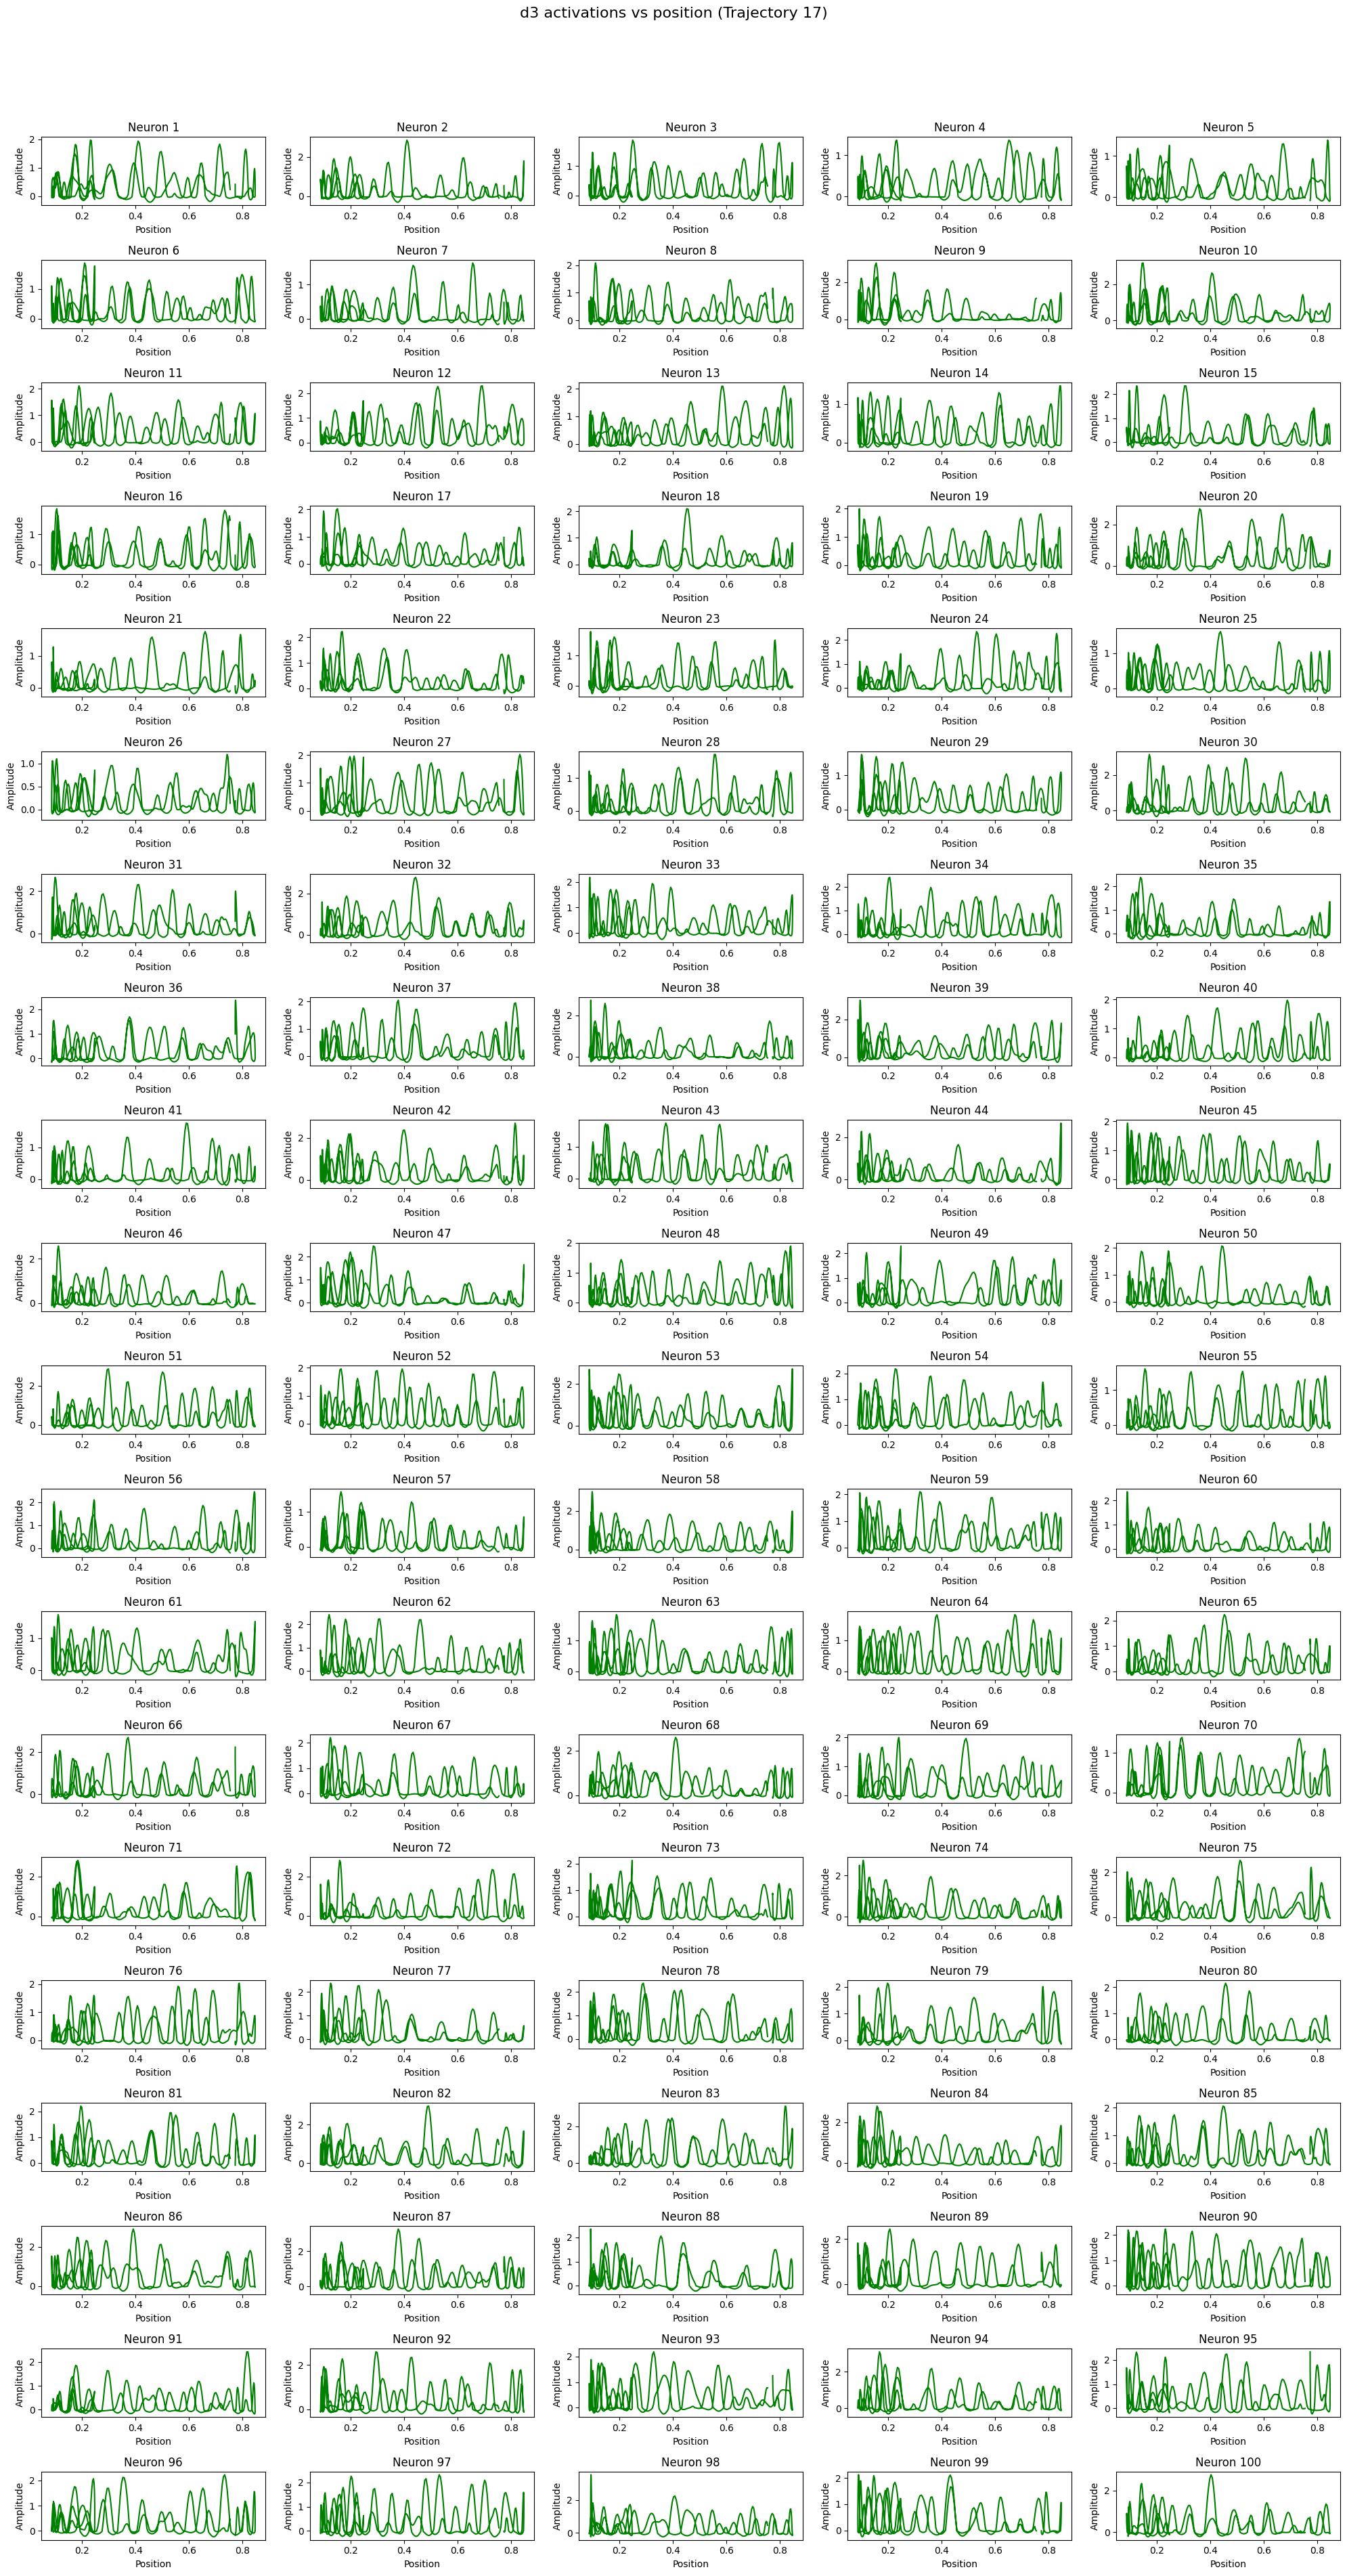

In [25]:
plot_activations_vs_position(
    activations,
    positions,
    layer_name=layer,
    trial=17
)

#### Calculate spatial_info and sparsity

In [29]:
# =====================================================
# Run the ORIGINAL pipeline for every trajectory
# =====================================================

all_results = []

for trial in range(positions.shape[0]):

    print(f"Processing trajectory {trial+1}/{positions.shape[0]}")

    pos = positions[trial]          # (500,2)
    act = activations[trial]        # (500,100)

    spatial_info, sparsity_scores, fpgrid, frm = get_scores(
        pos,
        act
    )

    place_cells = identify_place_cells(
        spatial_info,
        sparsity_scores,
        pos,
        act
    )

    all_results.append({
        "trial": trial,
        "spatial_info": spatial_info,
        "sparsity_scores": sparsity_scores,
        "place_cells": place_cells,
        "frm": frm,
        "fpgrid": fpgrid
    })

Processing trajectory 1/50


IndexError: tuple index out of range

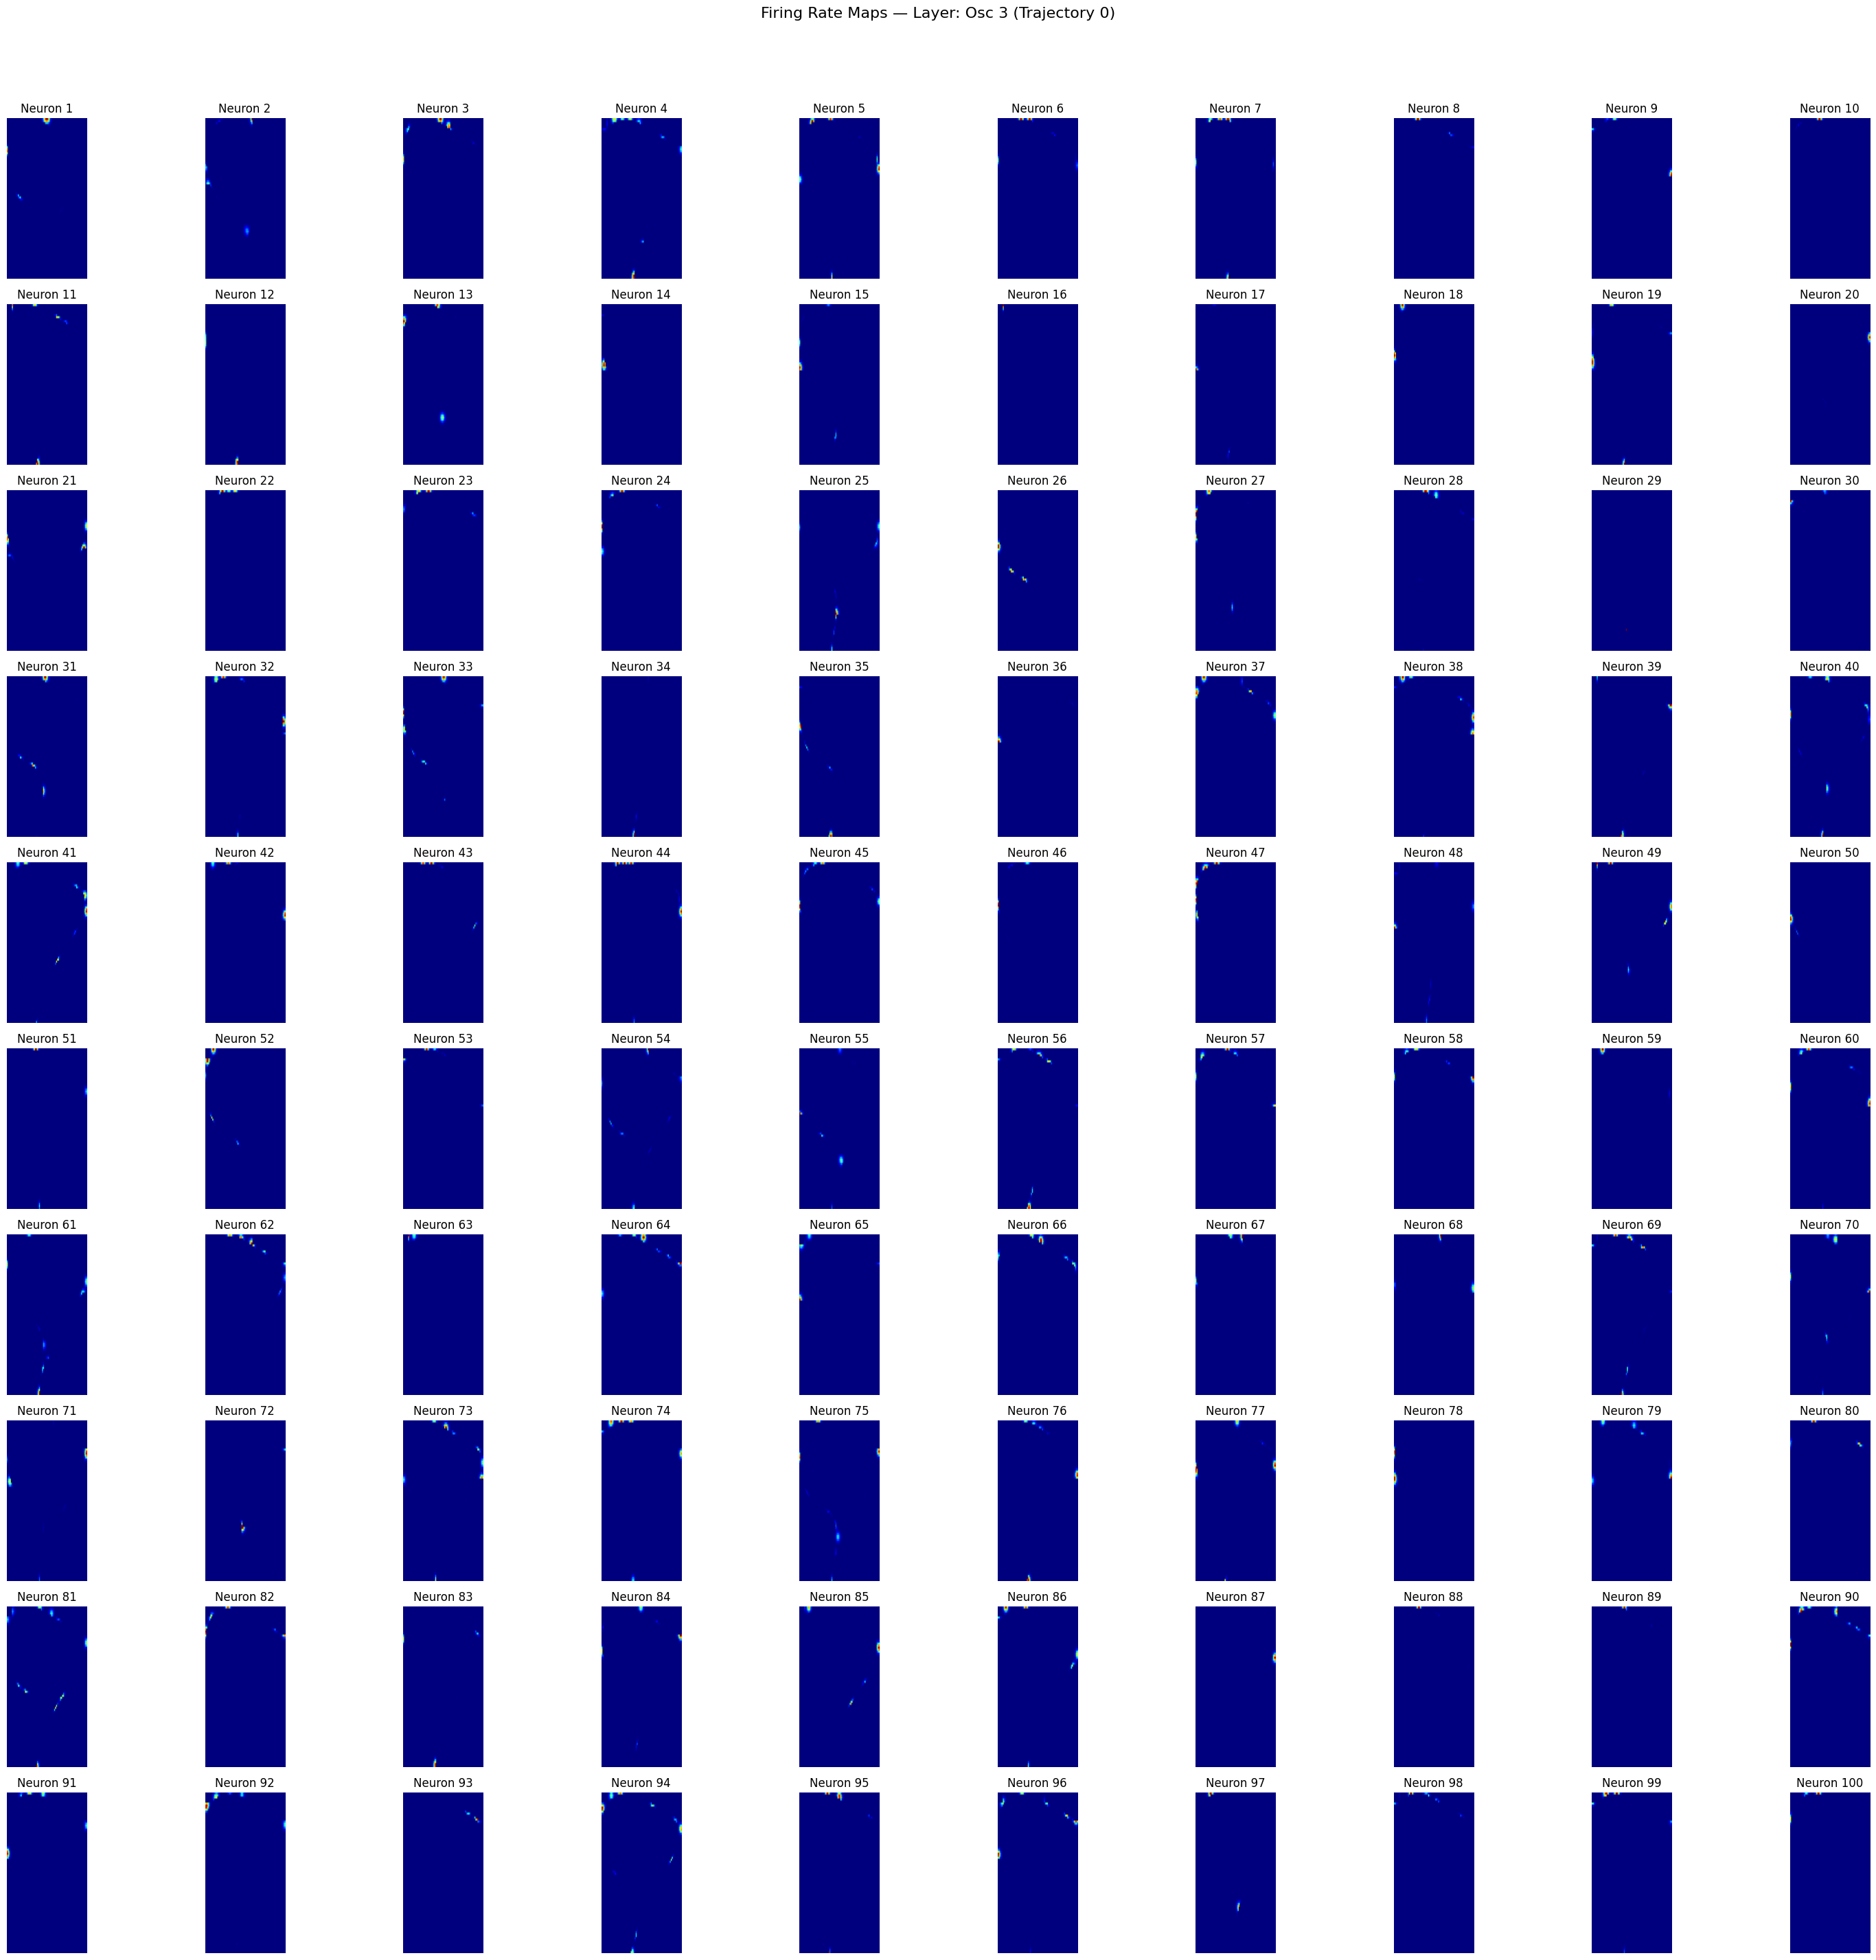

In [ ]:
#position_bins = plot_frm_vs_position_2d(frm, positions, layer, xedges, yedges)

In [ ]:
#got an issue, there is no function called position_bins, so I will need to define it

In [189]:
specific_locations = position_bins[frm[19] > 1]

TypeError: '>' not supported between instances of 'list' and 'int'

In [208]:
print(type(frm))
print(type(frm[0]))
print(type(frm[0][0]))
print(frm[0][0].shape)

<class 'list'>
<class 'list'>
<class 'numpy.ndarray'>
(80, 80)


In [211]:
print(type(position_bins))
print(position_bins)

<class 'NoneType'>
None


In [154]:
print(type(frm))

if isinstance(frm, list):
    print(len(frm))
    print(type(frm[0]))
    print(len(frm[0]))

<class 'list'>
50
<class 'list'>
100


In [24]:
print(specific_locations)

[0.48248343 0.49409861 0.50571379 0.51732897 0.52894415 0.54055933
 0.5521745  0.56378968 0.57540486]


In [25]:
def plot_frm_vs_position_single(frm, positions, layer_name, res_param=40):
    """
    Plots firing rate maps of all neurons in a single plot vs position.
    """
    positions = np.array(positions)  # Ensure it's a NumPy array
    x = np.linspace(positions.min(), positions.max(), frm.shape[1])
    num_neurons = frm.shape[0]

    plt.figure(figsize=(10, 6))
    for neuron_index in range(num_neurons):
        plt.plot(x, frm[neuron_index], label=f'Neuron {neuron_index + 1}', alpha=0.7)

    plt.title(f'Firing Rate vs. Position — Layer: {layer_name}', fontsize=14)
    plt.xlabel('Position')
    plt.ylabel('Firing Rate')
    if num_neurons <= 20:
        plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1.0), fontsize='small')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [26]:
print(f"Info Rate of all neurons: ", np.array(spatial_info))
print("="*50)
print(f"Sparsity Scores of all neurons: ", np.array(sparsity_scores))

Info Rate of all neurons:  [1.2  0.18 0.32 0.1  0.08 0.18 0.13 0.2  0.32 1.03 0.28 0.08 0.92 0.06
 0.14 0.13 0.18 0.36 0.14 3.33 0.21 1.32 0.43 1.01 0.17 3.23 0.97 0.07
 0.41 0.25 0.16 0.27 1.2  0.48 0.73 0.22 0.23 0.18 3.27 0.   0.21 0.9
 1.36 1.11 2.57 3.04 0.12 0.69 1.77 0.17]
Sparsity Scores of all neurons:  [0.08 0.22 0.25 0.38 0.38 0.24 0.35 0.19 0.14 0.17 0.25 0.36 0.12 0.41
 0.3  0.33 0.34 0.21 0.33 0.03 0.24 0.07 0.17 0.12 0.23 0.04 0.17 0.37
 0.29 0.38 0.25 0.17 0.08 0.13 0.07 0.23 0.21 0.28 0.04 0.   0.19 0.07
 0.07 0.1  0.15 0.04 0.36 0.11 0.13 0.27]


#### Identify place cells w. constraints:
Spatial Information Rate > 0.3 bits/spike

Sparsity Score < 0.1

In [27]:
spi_threshold = 0.3
spar_threshold = 0.1
place_cells = identify_place_cells(spatial_info, sparsity_scores, positions, activations)


Neurons selected wrt spatial_info:  [ 0  2  8  9 12 17 19 21 22 23 25 26 28 32 33 34 38 41 42 43 44 45 47 48]
Neurons selected wrt to sparsity:  [ 0 19 21 25 32 34 38 39 41 42 45]
Neurons satisfying both criteria:  [ 0 32 34 38 41 42 45 19 21 25]


In [28]:
print(len(place_cells))

10


In [29]:
place_cell_dict = get_scores_by_place_cells(place_cells, spatial_info, sparsity_scores)

In [30]:
for key, value in place_cell_dict.items():
    print(f"{key}:")
    print(value)
    print("-" * 50)  # Separator for better readability

place_cells_indices:
[np.int64(0), np.int64(32), np.int64(34), np.int64(38), np.int64(41), np.int64(42), np.int64(45), np.int64(19), np.int64(21), np.int64(25)]
--------------------------------------------------
spatial_info:
[np.float64(1.2), np.float64(1.2), np.float64(0.73), np.float64(3.27), np.float64(0.9), np.float64(1.36), np.float64(3.04), np.float64(3.33), np.float64(1.32), np.float64(3.23)]
--------------------------------------------------
sparsity_scores:
[np.float64(0.08), np.float64(0.08), np.float64(0.07), np.float64(0.04), np.float64(0.07), np.float64(0.07), np.float64(0.04), np.float64(0.03), np.float64(0.07), np.float64(0.04)]
--------------------------------------------------


In [31]:
print(place_cells)

[np.int64(0), np.int64(32), np.int64(34), np.int64(38), np.int64(41), np.int64(42), np.int64(45), np.int64(19), np.int64(21), np.int64(25)]


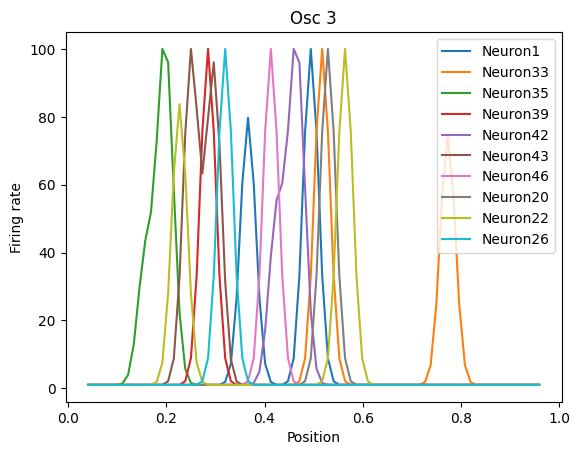

In [32]:
place_cells = np.array(place_cells)
'''
place_cell_activations = []
for i in place_cells:
    place_cell_activations.append(activations[:, i])

place_cell_activations = np.array(place_cell_activations)
place_cell_activations = place_cell_activations.reshape(200, 7)
print(place_cell_activations.shape)
'''
def plot_frm_vs_position_together(frm, forward_positions, layer_name, res_param=40):
    """
    Plots firing rate map of neurons in given layer vs position.

    Parameters:
    frm: Firing rate map of each neuron in given layer
    positions: numpy array of shape (time_steps, 1), containing positions at each timestep
    reso: Resolution used for the histogram
    """
    x = np.linspace(forward_positions[:,0].min(), forward_positions[:,0].max(), res_param*2)

    num_neurons = place_cells.shape[0]

    # num_rows = 30
    # num_cols = 5

    # plt.figure(figsize=(20, 2 * num_rows))
    # plt.suptitle(f'Firing rate vs Position for Layer: {layer_name}', fontsize=16)

    for i, neuron_index in enumerate(place_cells):
        #plt.plot(num_rows, num_cols, i+1)
        plt.plot(x, frm[neuron_index], label=f'Neuron{neuron_index+1}')
    plt.xlabel('Position')
    plt.ylabel('Firing rate')
    plt.title(layer_name)
        
    # plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.legend(loc='upper right')
    plt.show()
        #plt.ylim(global_min, global_max)  # Adjust as per the range of activation values
    

plot_frm_vs_position_together(frm, positions, layer_name, reso)

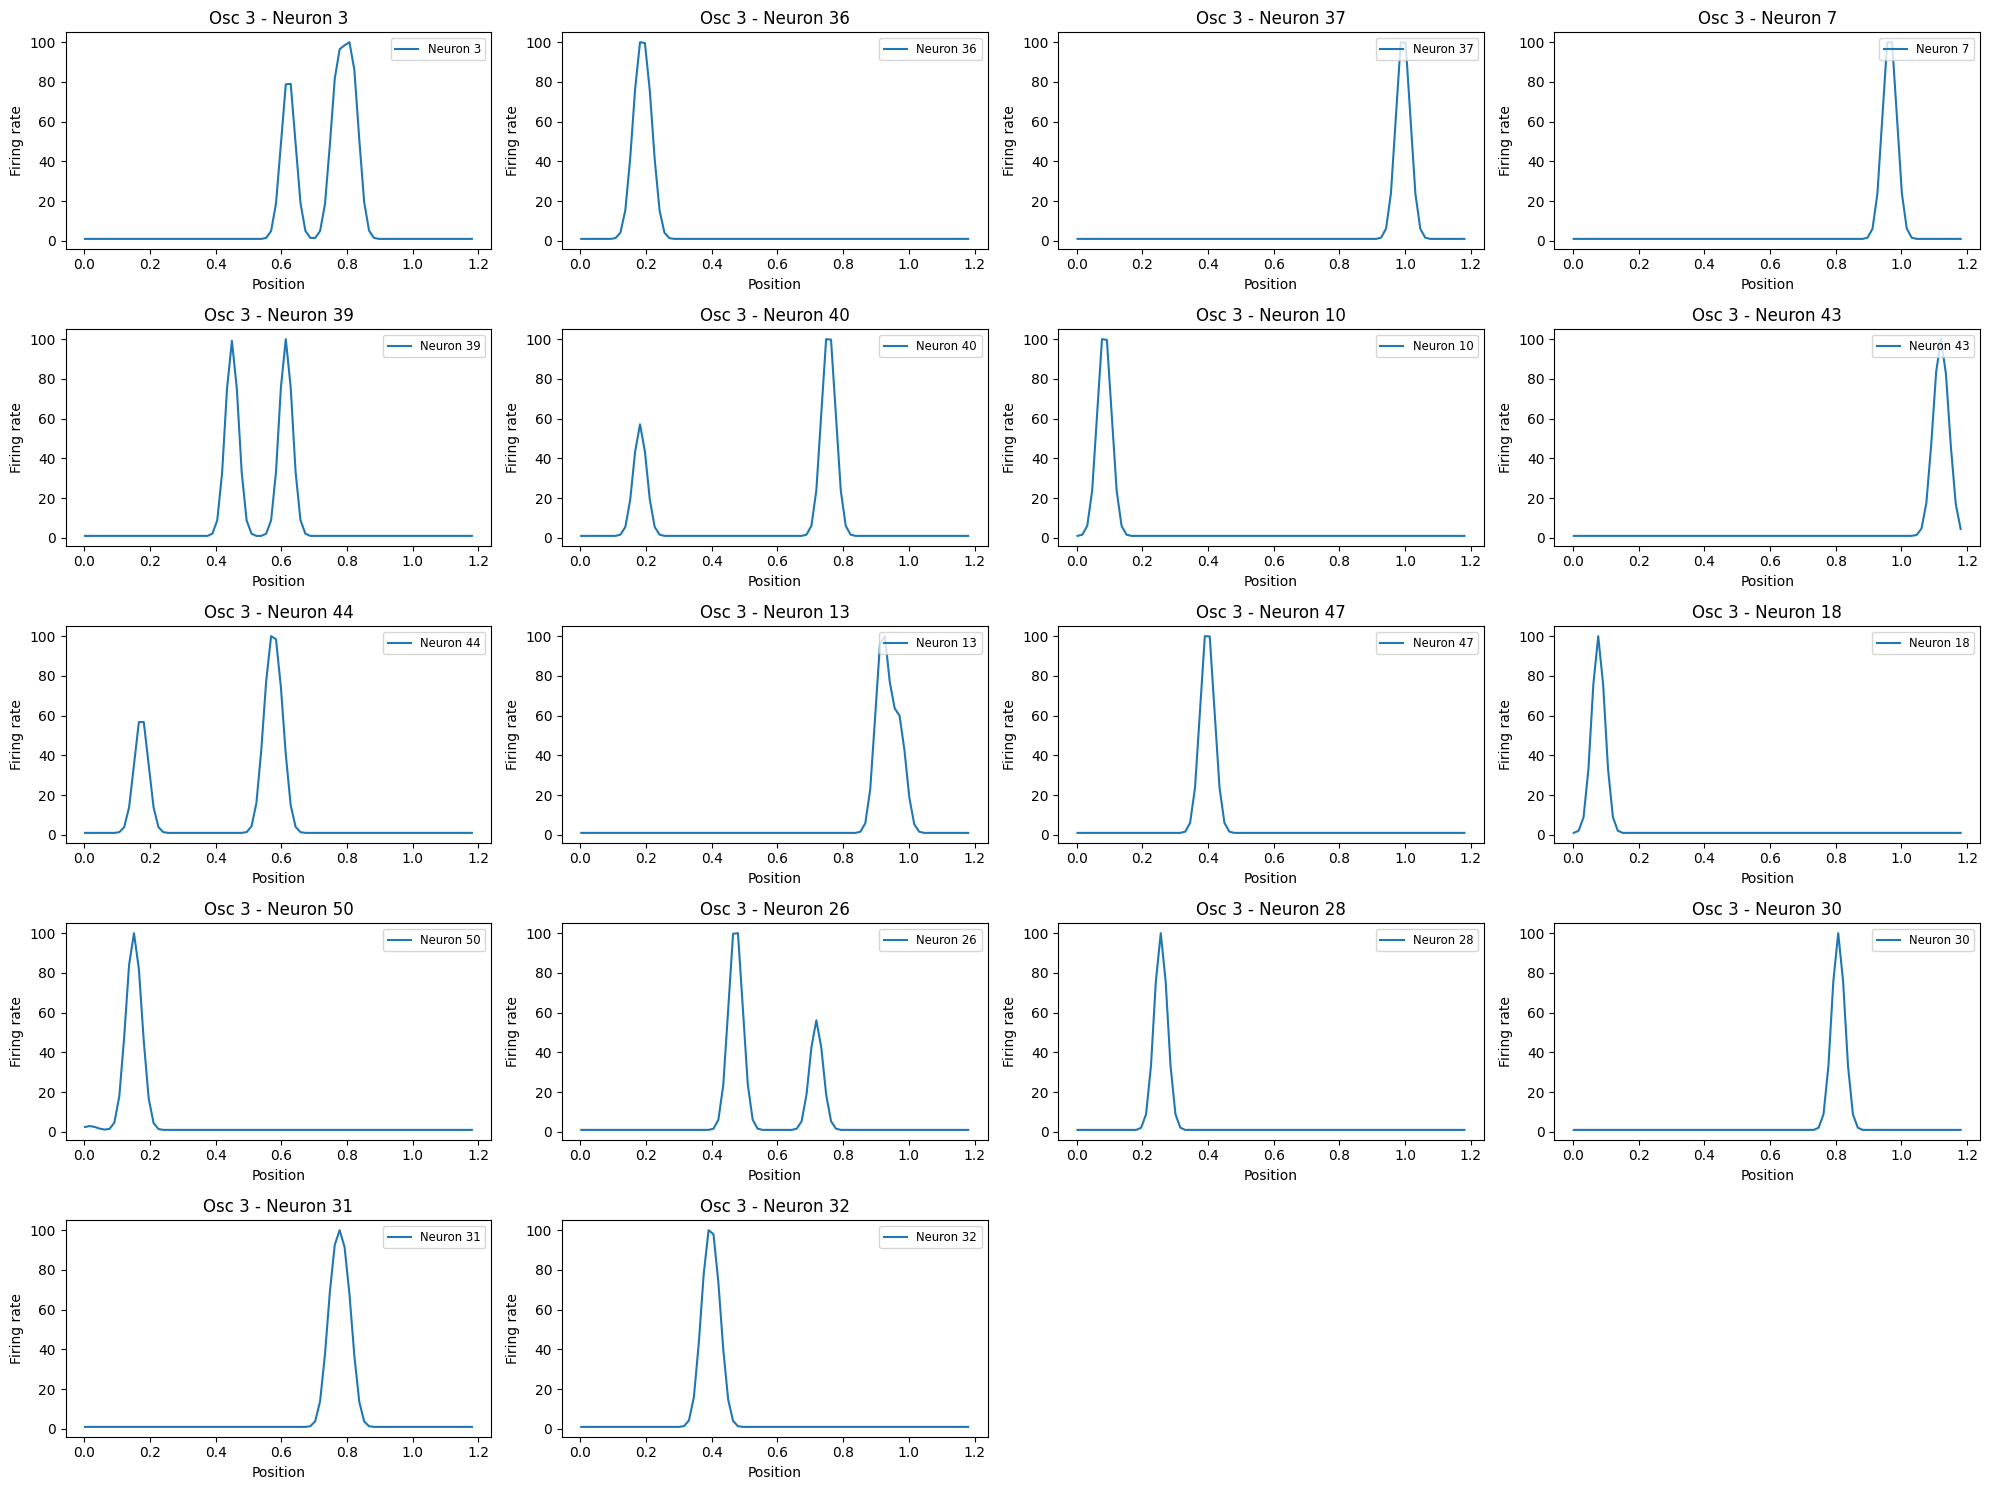

In [ ]:


place_cells = np.array(place_cells)
'''
place_cell_activations = []
for i in place_cells:
    place_cell_activations.append(activations[:, i])

place_cell_activations = np.array(place_cell_activations)
place_cell_activations = place_cell_activations.reshape(200, 7)
print(place_cell_activations.shape)
'''
def plot_frm_vs_position_together(frm, forward_positions, layer_name, res_param=40):
    """
    Plots firing rate map of neurons in given layer vs position.

    Parameters:
    frm: Firing rate map of each neuron in given layer
    positions: numpy array of shape (time_steps, 1), containing positions at each timestep
    reso: Resolution used for the histogram
    """
    x = np.linspace(forward_positions[:,0].min(), forward_positions[:,0].max(), res_param*2)

    num_neurons = place_cells.shape[0]

    # num_rows = 30
    # num_cols = 5

    # plt.figure(figsize=(20, 2 * num_rows))
    # plt.suptitle(f'Firing rate vs Position for Layer: {layer_name}', fontsize=16)

    for i, neuron_index in enumerate(place_cells):
        #plt.plot(num_rows, num_cols, i+1)
        plt.plot(x, frm[neuron_index], label=f'Neuron{neuron_index+1}')
    plt.xlabel('Position')
    plt.ylabel('Firing rate')
    plt.title(layer_name)
        
    # plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.legend(loc='upper right')
    plt.show()
        #plt.ylim(global_min, global_max)  # Adjust as per the range of activation values
    

plot_frm_vs_position_together(frm, positions, layer_name, reso)